## 天气数据分析

In [16]:
import pandas as pd
# 加载天气数据
df = pd.read_csv("../data/weather.csv")
df
# 查看基本属性信息
df.shape
df.columns
df.dtypes
# df.info()

# 查看前5行天气情况
df.head()
# 查看后10行天气情况
df.tail(10)

# 加载一列数据
df["date"]  # 没有加中括号，得到的是Series类型对象
df[["date"]]   # 如果加中括号，得到的是dataframe类型对象

# 加载多列数据
# df[["date","temp_max","temp_min"]]




,date
0,2012-01-01
1,2012-01-02
2,2012-01-03
3,2012-01-04
4,2012-01-05
...,...
1456,2015-12-27
1457,2015-12-28
1458,2015-12-29
1459,2015-12-30


In [29]:
# 获取指定位置数据
# 获取行标签为1的数据
df.loc[1]
# 获取行标签分别为1、10、100的数据
df.loc[[1,10,100],["temp_max","temp_min"]]
# 获取行位置为0的数据
df.iloc[0]
# 获取行位置为最后一位的数据
df.iloc[-1]
# 获取行标签为1，列标签为precipitation的数据
df.loc[1,"precipitation"]
# 获取所有行，列标签为precipitation的数据
df.loc[:,"precipitation"]
# 获取所有行，列位置为3，5，最后一位的数据
df.iloc[:,[3,5,-1]]
# 获取前10行，列位置为2、3、4、5的数据
df.iloc[:10,2:6]
# 通过行列标签获取数据



,temp_max,temp_min,wind,weather
0,12.8,5.0,4.7,drizzle
1,10.6,2.8,4.5,rain
2,11.7,7.2,2.3,rain
3,12.2,5.6,4.7,rain
4,8.9,2.8,6.1,rain
5,4.4,2.2,2.2,rain
6,7.2,2.8,2.3,rain
7,10.0,2.8,2.0,sun
8,9.4,5.0,3.4,rain
9,6.1,0.6,3.4,rain


<Axes: xlabel='month'>

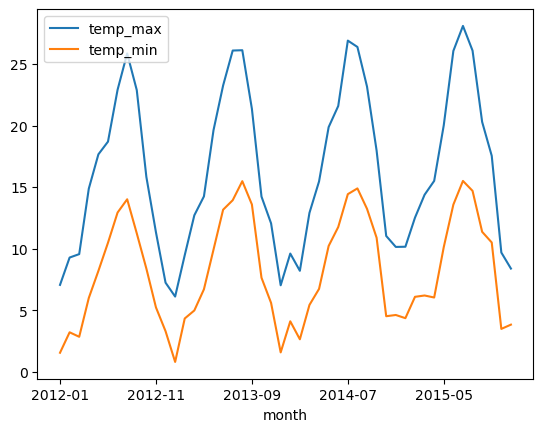

In [51]:
# 分组聚合
# mysql :  select 分组字段,聚合函数 from 表 group by 分组字段
# df.groupby("分组字段")["要聚合的字段"].聚合函数()
# df.groupby(["分组字段", "分组字段2", ...])[["要聚合的字段", "要聚合的字段2", ...]].聚合函数()

# （1）将数据按月分组，并统计最大温度和最小温度的平均值
df["month"] = pd.to_datetime(df["date"]).dt.to_period("M").astype(str)

month_group = df.groupby("month")
stat_column = month_group[["temp_max","temp_min"]]
stat_column.mean()

# df.groupby("month")[["temp_max","temp_min"]].mean()


# 统计每个月不同天气状况的数量
df.groupby("month")["weather"].nunique()

df.groupby("month")[["temp_max", "temp_min"]].mean().plot()



In [58]:
import numpy as np
df[["temp_max","temp_min"]].describe(include=np.float64).T


,count,mean,std,min,25%,50%,75%,max
temp_max,1461.0,16.439083,7.349758,-1.6,10.6,15.6,22.2,35.6
temp_min,1461.0,8.234771,5.023004,-7.1,4.4,8.3,12.2,18.3


In [65]:
# （1）找到最高温度最大的30天
df.nlargest(30,"temp_max")

# （2）从最高温度最大的30天中找出最低温度最小的5天
df.nlargest(30,"temp_max").nsmallest(5,"temp_min")

# （3）找出每年的最高温度
# df["year"] = pd.to_datetime(df["date"]).dt.year
# df.groupby("year")["temp_max"].max()

year_sort = df.sort_values(by=["year","temp_max"],ascending=[True,False])

year_sort.drop_duplicates(subset=["year"])

,date,precipitation,temp_max,temp_min,wind,weather,month,year
228,2012-08-16,0.0,34.4,18.3,2.8,sun,2012-08,2012
546,2013-06-30,0.0,33.9,17.2,2.5,sun,2013-06,2013
953,2014-08-11,0.5,35.6,17.8,2.6,rain,2014-08,2014
1295,2015-07-19,0.0,35.0,17.2,3.3,sun,2015-07,2015
